In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

print("All libraries ready. Starting Iris EDA.")

All libraries ready. Starting Iris EDA.


### Section 1
### Task 1
- Task 1. Load the dataset using sklearn.datasets.load_iris() and convert to a pandas DataFrame. Add the target column as species names (not numbers). Print the first 5 rows.

`Observation`
- imported successfully dataset
- change name of the target col to species
- also replaced integer value in target col to the actual species names

In [3]:
from sklearn.datasets import load_iris

### About Iris Dataset 
- It is one of the most commonly used dataset in the ml and statistic 
- It contains 150 records from 5 attributes -> sepal length, sepal width, petal length, petal width, Target
- It contains 3 species of the flower -> Iris Sentosa, Iris Virginica, Iris Virsicolor 
- Sepal is the leaf-like structure of the flower and Petal is the coloured structure of the flower
- It is created to distinguish between the 3 species of the Iris flower using sepal and petal measurements

In [4]:
iris = load_iris(as_frame=True)
df = iris.frame
df1 = iris.feature_names
df2 = iris.target_names

This function is to convert target col number to the actual value of the species

In [5]:
def conver_target_col(num):
  if num == 0:
    return 'setosa'
  elif num == 1:
    return 'versicolor'
  else:
    return 'virginica'

In [6]:
df.rename(columns={
    'target': 'species'
}, inplace=True)

In [7]:
df['species'] = df['species'].apply(conver_target_col)

In [8]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Task 2 (Statistical summary)
- Task 2. Run df.info() and df.describe(). In a markdown cell below, write: (a) how many rows and columns, (b) any null values?, (c) what data types are present.

`Observation`
- 150 rows and 5 columns present
- All datatypes are correct and no null values found

`key Obvervations`
- 150 non-null values are there out of 150
- all 4 main measurement features are in float datatype and 'species' datatype is in object
- sepal length has highest mean among all and petal length has highest standard deviation among all
- petal_width has smallest standard deviation
- the large difference in the petal length of 5.9 shows suggesting high variability due to 3 different species


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Task 3
- Task 3. Check class balance using df['species'].value_counts(). Is the dataset balanced? Write your answer in a markdown cell.

`Oberservation`
- the result dhows that the data is properly balanced as all three species contains 50 records each
- In ML, if one class had 100 samples and the other is very low i.e. 25 samples this shows the imbalance in the dataset and the model than gets the biased toward more samples species thats why data should be distributed equally

In [11]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Section 2
### Task 4
- Task 4. Plot a histogram for all 4 features using df.hist(bins=20, figsize=(10,6)). For each feature, identify: is it normally distributed? Any skew visible?

`Observation`
- sepal_length -> There are 2 peaks of length 5.0 and nearly 6.3 and have more than 15 flowers(not properly distributed contains skewness a little)
- sepal_width -> Here more than 25 flowers have 3.0 cm width, It shows sepal width max flowers lies in between 2.5 to 3.5, it is almost properly distributed 
- petal_length -> It contains 2 peaks on different length and a range of length have 0 flowers, It is a bimodal Distribution
- petal_width -> It also has 2 peaks and a range that have 0 flower, It is also bimodal distribution
- The gap in the petal feature suggest that there exist of two distinct group, likely setosa vs versicolor/virginica.


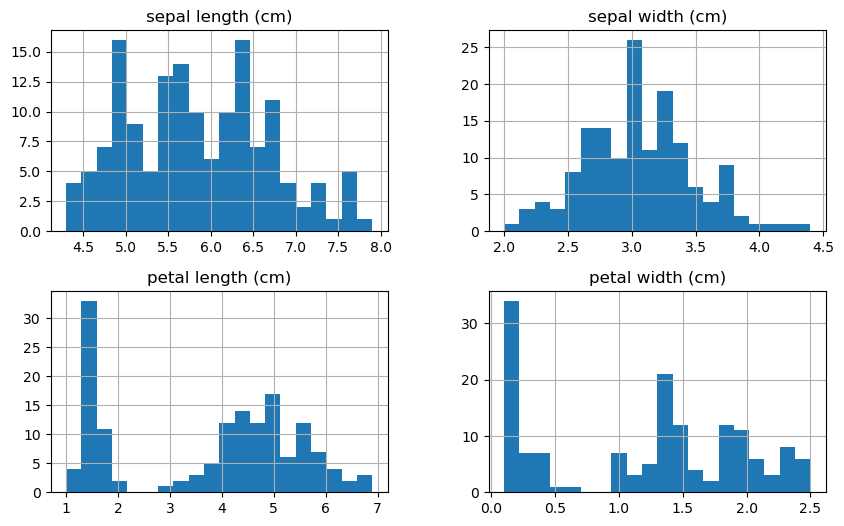

In [12]:
df.hist(bins=20,figsize=(10,6))
plt.show()

### Task 5
- Task 5. Plot boxplots for all 4 features side by side. Identify any outliers. Which feature has the most spread (largest IQR)?

`Oberservation`
- sepal length is noramally distributed and have outliers, only have a little stretched upper limit wisker
- sepal width it contains some outliers on both the side which shows inconsistency and unstability of the data, also have less values in the median due to less middle 50% of the data
- petal length have a large box means variable data between Q1 and Q3 and also median is towards on upper side due to larger values, longer upper whisker which shows that 25% data below that,
mean overall conclusion is that 75% data is on upper side conjested and below 25% data is more spreaded and have larger values to gain the variablity of the data
- petal width have small box means small value in middle, median is on upper side and also the upper whisker is longer
- petal length has a larget IQR = 3.5 which is largest among all features

`More`
- In sepal length the virginica contains a outlier which can be correct or a data error
- In sepal width setosa and virginica contains outliers on both the side also setosa upper whisker is larger states all values concentrated 
- In petal length almost all median are in center also setosa contains more outliers than versicolor 
virginica has more spreaded value as its upper whisker is larger
- same for petal width setosa contains outliers but not other 2 also have median at very bottom 

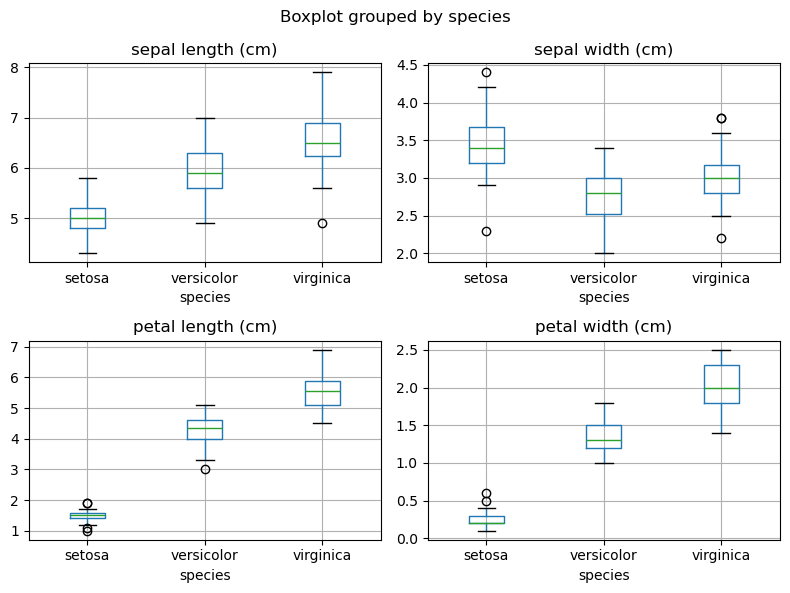

In [13]:
features = ['sepal length (cm)',	'sepal width (cm)',	'petal length (cm)',	'petal width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(8,6))
axes = axes.flatten()
for i, feature in enumerate(features):
  df.boxplot(column=feature, by='species', ax=axes[i])

plt.tight_layout()
plt.show()


In [14]:
df['petal length (cm)'].quantile(0.75) - df['petal length (cm)'].quantile(0.25)

np.float64(3.4999999999999996)

### Task 5
- Compute skewness for all features using df.skew(). Which feature is most skewed? Is it positive or negative skew?

`Oberservation`
- I can clearly see that no feature is very much skewwed 
- sepal length and width are positively skewwed a little
- petal length and width are negatively skewwed a little in which petal width is almost comes in normal distribution 
- petal width is most least skewed -> -0.102967
- Noo long transformation needed for the dataset all values lies in safe range of -1 to +1

In [15]:
df.skew(numeric_only=True)

sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64

### Section 3(Bivariate analysis)
### Task 5

Task 7. Create a correlation heatmap using sns.heatmap(df.corr(numeric_only=True), annot=True). Which two features are most correlated? Which are least?

`Oberservation`
- sepal length has highly positive correlation with petal width and length also negative with sepal width
- sepal width has negative correction with all three features and more from petal measurements
- petal length has strong positve correlation with petal width 0.96 and negative with sepal width -0.43
- petal width has strong correlation with petal length 0.96 and negative with sepal width -0.37
- petal_length and petal_width are 96% correlated — in ML this can cause multicollinearity, meaning we may only need one of them as a feature.
- flowers with longer sepal length have longer petal measurements and shortest sepal width
- flowers with longer the petal length have wider the petal too

<Axes: >

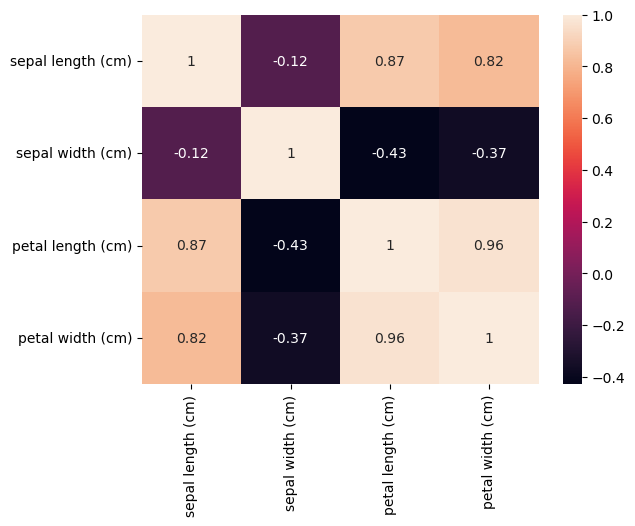

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

### Task 8
- Plot a scatter plot of petal_length vs petal_width with species as color using seaborn. Can you visually separate the 3 species?

`Observation`

`petal L vs W`
- setosa(blue) species is properly separated and clusterd between petal length 1-2
- virsicolor and virginica is not properly serparable
- overlap between versicolor and virginica is there between petal length 4.5 to 5.5
- The overlap between versicolor and virginica means a simple linear model may struggle — a more complex boundary will be needed.

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

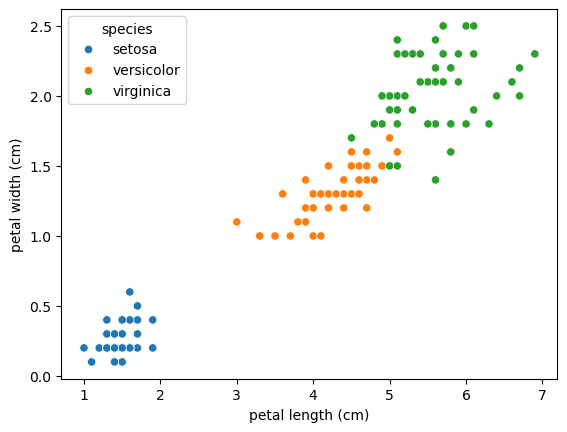

In [17]:
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species')

### Task 9
- Task 9. Now plot the same scatter but use sepal_length vs sepal_width. Compare the class separation to Task 8. Which feature pair is better for classification?

`Observation`
- We can clearly see that setosa is separated from other two species 
- Setosa also has some outliers as we see in the scatterplot and after sepal length 5.5 and width 4 there are more outliers also one is in the bottom which is due to sepal width 
- virginica and versicolor is overlapped together around septal length 6.5 also has many outliers are there in both
- So as we conclude this by saying that setosa species is consistent and tightest species compare to other two, but In virsicolor and virginica its very difficult to distinguish them due to overlapping of both the measurments type sepal and petal

- Therefore petal features are far better for classification for models, they show less overlapping between three species and sepal features shows heavy mixing across all three species

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

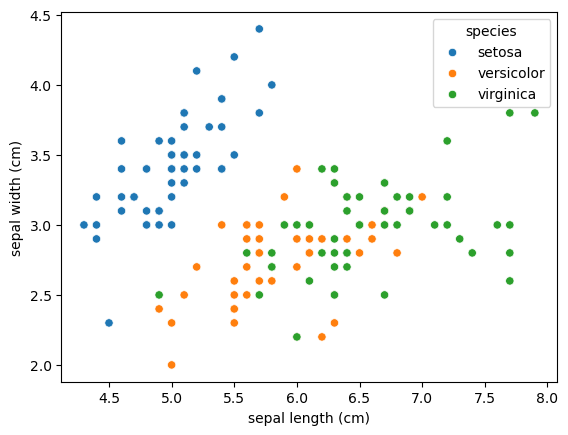

In [18]:
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='species')

### Task 10 (Multivariate analysis)
- Plot a pairplot using sns.pairplot(df, hue='species'). Identify which single feature best separates all 3 classes on its own (look at the diagonal).

`Observation`
- petal length shows 3peaks here, where setosa is separated completely and virsicolor and virginica are overlap a little
- petal length is the best single feature to separate all 3 species 
- sepal width is the worst single feature for classification most overlapped around 3 features
- petal width also shows good separation hence both petal features are good and strong for classifires individually

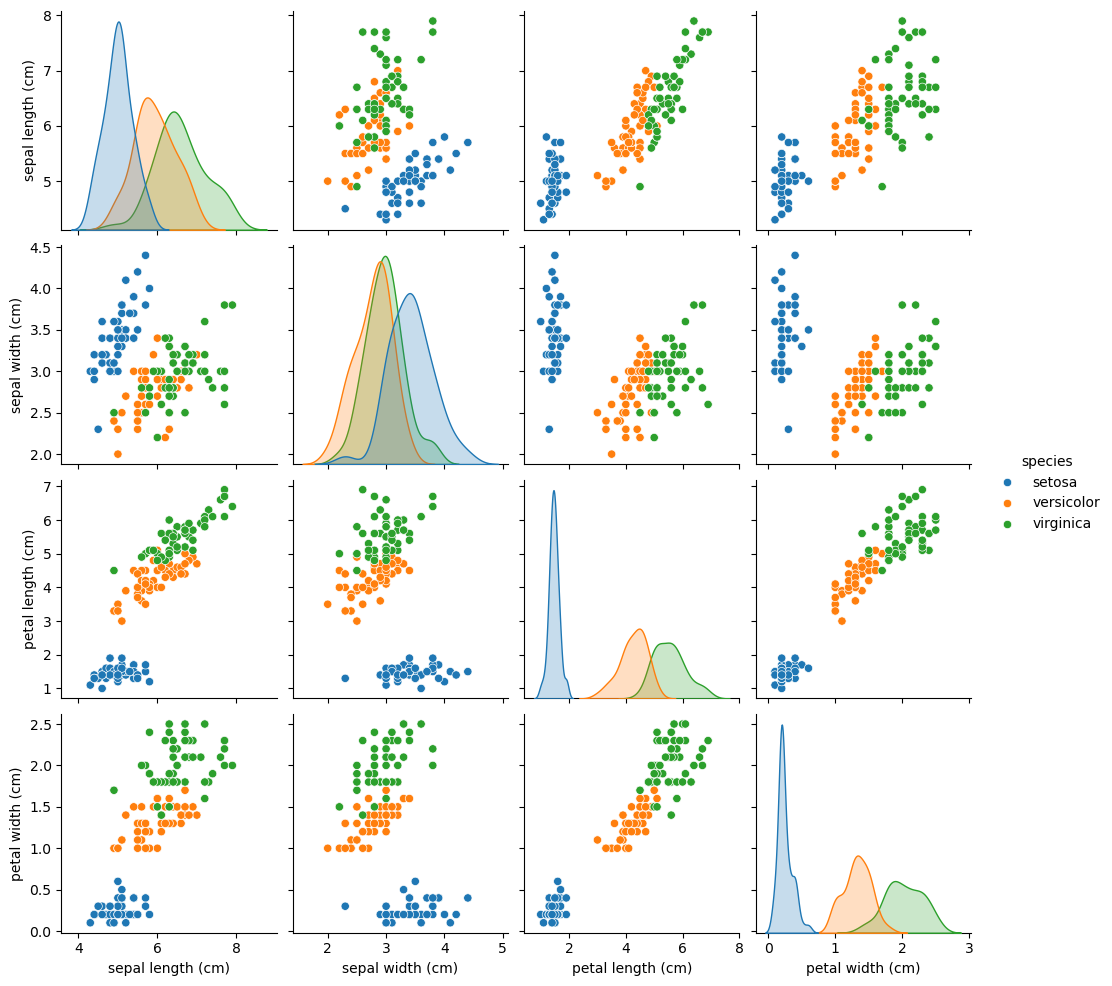

In [19]:
sns.pairplot(df, hue='species')

### Task 11
- Compute groupby('species').mean() for all features. Build a table in markdown showing mean values per species. What pattern do you see across species?

`Observation`
- Among all three species virginica has highest mean value for sepal length petal lenght and petal width, means its a largest species on measurments
- setosa is the smallest species among all, has lowest mean
- but sepal width breaks this pattern, as you see despite being the smallest species setosa has highest mean in sepal width and virginica has lowest mean
This makes the sepal width the most inconsistent feature for classification

| Species    | sepal_length | sepal_width | petal_length | petal_width |
|------------|-------------|-------------|--------------|-------------|
| setosa     | 5.006       | 3.428       | 1.462        | 0.246       |
| versicolor | 5.936       | 2.770       | 4.260        | 1.326       |
| virginica  | 6.588       | 2.974       | 5.552        | 2.026       |

In [20]:
df.groupby('species').mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


### Task 12
- Plot a violin plot of petal_length grouped by species using seaborn. How does it add information beyond a boxplot?

`Obersevation`
- Setosa flower is narrow and compact shows that data is clustered in a small region for similar measurments of petal length (1-2cm) there is very high frequency
- Versicolor has wider in middle(4-5 cm) shows high frequency of flowers around its median
- virginica upper violin is steap denoting low frequency of the flower in that petal length range (above 6 cm) and has large frequency in the middle and lower violin (4.5 - 6 cm) 
- Violin is different from boxplot because of one thing that is showing frequency or concentration or density of the data for any categorical value 

<Axes: xlabel='species', ylabel='petal length (cm)'>

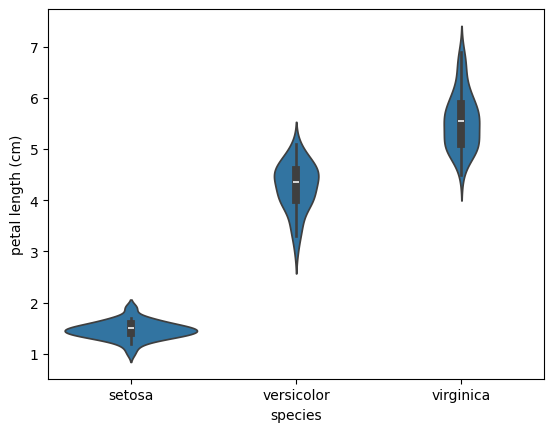

In [21]:
sns.violinplot(data=df, x='species', y='petal length (cm)')

### Task 13 (Insight summary & preprocessing prep)
- Check for outliers using the IQR method manually (not a library). Flag any row where a feature value falls below Q1 − 1.5×IQR or above Q3 + 1.5×IQR. How many outlier rows exist?

`Observation` 
- Sepal width has maximum outliers 4
- 0 outliers in petal features tell that there is no deviation in the data point
- This data is clear that real world data
- With only 4 outliers in sepal_width out of 150 rows, removal is optional

In [22]:
Q1 = df.quantile(q=0.25, axis=0, numeric_only=True,interpolation='linear')
Q3 = df.quantile(q=0.75, axis=0, numeric_only=True,interpolation='linear')

IQR = Q3 - Q1

is_below = Q1 - 1.5*IQR
is_above = Q3 + 1.5*IQR


for col in df.select_dtypes(include='number').columns:
  outliers = ((df[col] < is_below[col]) | (df[col] > is_above[col])).sum()
  print(f"{col}: {outliers} outliers")



sepal length (cm): 0 outliers
sepal width (cm): 4 outliers
petal length (cm): 0 outliers
petal width (cm): 0 outliers


### Task 14 
- Apply StandardScaler to all 4 numerical features and compare the mean and std before vs after scaling. What should mean and std be after scaling?

`Observation`
- So in machine leanring value of the features can be in different ranges and units. For example a features salary has range minimum from 10000 but the another features age only has the range to maximum till 100 so this difference can cause negative performance of the algorithm like KNN, SVM and logistic Regression. To avoid this issue we have to standardize the data and we use feature scaling

- We have first feature scaling method StandardScaler which standardize the value. It transform the data so that the mean becomes 0 and standard deviation becomes 1

- Mean and Standard Deviation here is all near 0 and 1 

In [26]:

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.select_dtypes(include='number'))
df_scaled = pd.DataFrame(df_scaled, columns=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'])

print('Scaled dataset')
df_scaled.head()

Scaled dataset


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [33]:
print('Before Scaling')
print(df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']].agg(['mean', 'std']))

print('\nAfter Scaling')
print(df_scaled[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']].agg(['mean', 'std']))

Before Scaling
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean           5.843333          3.057333           3.758000          1.199333
std            0.828066          0.435866           1.765298          0.762238

After Scaling
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean      -4.736952e-16     -7.815970e-16      -4.263256e-16     -4.736952e-16
std        1.003350e+00      1.003350e+00       1.003350e+00      1.003350e+00


### Task 15
### CONCLUSION
`Overview`
- It is one of the most commonly used dataset in the ml and statistic 
- It contains 150 records from 5 attributes -> sepal length, sepal width, petal length, petal width, Target
- It contains 3 species of the flower -> Iris Sentosa, Iris Virginica, Iris Virsicolor 
- Sepal is the leaf-like structure of the flower and Petal is the coloured structure of the flower
- It is created to distinguish between the 3 species of the Iris flower using sepal and petal measurements

`Key Insights`
- Sepal width has maximum outliers 4 (removal Optional)
- Petal length is the best feature among all for classification of all three species
- There no null value this dataset contains
- Among all three species setosa is smallest and virginica is largest
- Sepal width behaves different for all three species

`Best features`
- The best features for ml work is petal length which has less outliers and best for classification have very less overlapping between species

`Best Model`
- I dont know about models as of now but i think logistic regression would be good